# Replica of the scITD Analysis

The goal of this ntoebook is to replicate, on the breast-cancer data which is provided, the analysis which scITD conducts in order to gain insight on how tensor decompositions can be used to meaningfully analyse cell-cycle data.

## 0. Imports:

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

from itertools import product

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly.decomposition import tucker
from tensorly import tenalg

## 1. Data import:

In [3]:
adata = sc.read_h5ad("../data/breast_cancer_zikry_wayne/T47D_merged.h5ad")

We subset to the following features:

In [4]:
selected_features = [
    'nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX',
    'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
    'nuclear_mean_CDK2','nuclear_mean_cycE1', 'nuclear_mean_pRB',
    'nuclear_mean_PH3','nuclear_mean_cycA2','nuclear_mean_Plk1',
    'DNA_int'
]

adata = adata[:, selected_features]

Understanding our data:

In [5]:
print(f'n_obs x n_vars: {adata.shape}')

n_obs x n_vars: (612372, 13)


In [6]:
print(f'cell barcodes (row index): {adata.obs_names}\n')
print(f'gene/feature names (column index): {adata.var_names}\n')

cell barcodes (row index): Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '144088', '144089', '144090', '144091', '144092', '144093', '144094',
       '144095', '144096', '144097'],
      dtype='object', length=612372)

gene/feature names (column index): Index(['nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX',
       'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
       'nuclear_mean_CDK2', 'nuclear_mean_cycE1', 'nuclear_mean_pRB',
       'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
       'DNA_int'],
      dtype='object')



In [7]:
adata.obs

,core,binucleated,CellID,GMM_phase_labels,DNA_int_obs,nuclear_mean_cycA2_obs,Endocycle,drug_name
0,1.0,1,0,G0,4.514192,162.493695,Polyploid,Control
1,1.0,0,1,S,4.379941,2641.722167,Diploid,Control
2,1.0,0,2,G0,5.348979,159.590886,Polyploid,Control
3,1.0,0,3,G1,2.106505,181.602243,Diploid,Control
4,1.0,0,4,G0,1.826259,155.153846,Diploid,Control
...,...,...,...,...,...,...,...,...
144093,8.0,0,144093,G1,2.205912,240.395580,Diploid,Dinaciclib
144094,8.0,0,144094,G1,2.033355,193.921158,Diploid,Dinaciclib
144095,8.0,0,144095,G0,2.081168,531.183796,Diploid,Dinaciclib
144096,8.0,0,144096,G0,1.971715,174.206118,Diploid,Dinaciclib


In [8]:
total = adata.obs['drug_name'].value_counts().sum()
adata.obs['drug_name'].value_counts() / total

drug_name
Dinaciclib      0.235311
RO-3306         0.224222
Palbociclib     0.151197
Control         0.099938
CVT-313         0.095159
PF-3600         0.081302
Samuraciclib    0.062359
Talazoparib     0.050512
Name: count, dtype: float64

In [9]:
pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

,nuclear_mean_HES1,nuclear_mean_p53,nuclear_mean_pH2AX,nuclear_mean_CDC25c,nuclear_mean_CycB1,nuclear_mean_p16,nuclear_mean_CDK2,nuclear_mean_cycE1,nuclear_mean_pRB,nuclear_mean_PH3,nuclear_mean_cycA2,nuclear_mean_Plk1,DNA_int
0,1485.613967,874.170223,2136.317653,234.709505,144.751212,2291.766731,5140.916586,800.507759,396.525703,600.428710,162.493695,188.823472,4.514192
1,1413.356859,1606.262922,1990.681909,235.934394,890.022366,1807.549205,4706.368290,552.378231,1670.795726,1148.586481,2641.722167,461.421471,4.379941
2,1368.803379,654.787506,3116.836918,233.526370,113.201229,1756.368920,1368.954685,631.483871,246.571173,592.180748,159.590886,135.884537,5.348979
3,1446.301122,2701.823986,1445.127696,243.163072,136.157895,1651.933563,2357.413287,698.044003,1072.846419,424.948231,181.602243,125.374461,2.106505
4,1468.494675,1321.991716,2089.118343,226.636686,156.211834,2620.850888,2153.565680,605.657988,297.229586,464.481657,155.153846,180.403550,1.826259
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144093,1671.966851,1571.782320,1242.919337,285.314917,200.794475,2393.575691,2223.079558,660.495028,1109.131492,589.051934,240.395580,182.297238,2.205912
144094,1514.709581,2393.952096,1273.376248,279.006986,140.104790,1202.762475,3536.428144,543.082834,578.515968,1085.689621,193.921158,507.659681,2.033355
144095,1513.505626,1277.599400,1604.366092,251.532633,451.711928,1236.012003,1886.015754,740.874719,384.794449,385.189047,531.183796,223.363091,2.081168
144096,1652.708706,1218.363765,948.016471,255.629647,115.259294,1834.586824,1305.151059,523.526588,173.493176,359.054118,174.206118,161.687529,1.971715


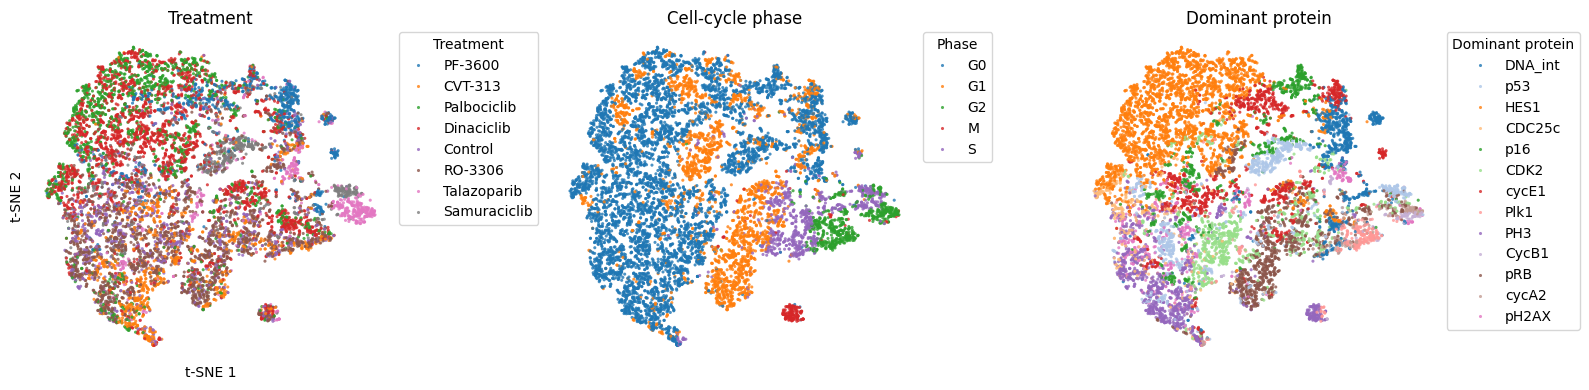

In [10]:
dot_size = 5

# t-SNE on a sampled subset
adata_tsne = sc.pp.subsample(adata, n_obs=min(10000, adata.n_obs), copy=True, random_state=0)

sc.pp.scale(adata_tsne, zero_center=True, max_value=10)
sc.tl.pca(adata_tsne, svd_solver="arpack")
sc.tl.tsne(adata_tsne, use_rep="X_pca", random_state=0)

tsne = pd.DataFrame(
    adata_tsne.obsm["X_tsne"],
    columns=["t-SNE 1", "t-SNE 2"],
    index=adata_tsne.obs_names,
)
tsne["treatment"] = adata_tsne.obs["drug_name"].astype(str).values
tsne["phase"] = adata_tsne.obs["GMM_phase_labels"].astype(str).values
tsne["protein"] = np.asarray(adata_tsne[:, "DNA_int"].X).ravel()


# Set up visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.despine(top=True, right=True, left=True, bottom=True)


# Treatment
sns.scatterplot(
    data=tsne, x="t-SNE 1", y="t-SNE 2", hue="treatment",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Treatment")
axes[0].legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Cell-cycle phase
sns.scatterplot(
    data=tsne, x="t-SNE 1", y="t-SNE 2", hue="phase",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Cell-cycle phase")
axes[1].legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Dominant protein per sample
dominant_protein = adata_tsne[:, selected_features].to_df().idxmax(axis=1)
tsne["dominant_protein"] = dominant_protein.str.removeprefix("nuclear_mean_").values

sns.scatterplot(
    data=tsne, x="t-SNE 1", y="t-SNE 2", hue="dominant_protein",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[2], palette="tab20"
)
axes[2].set_title("Dominant protein")
axes[2].legend(
    title="Dominant protein", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)


# Final touches
for ax in axes:
    if ax == axes[0]: 
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
    else: 
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 2. Data analysis:

Our idea is to, for a first go, model our tensor via: $\textit{treatment} \times \textit{cell-cycle phase} \times \textit{protein}$. Let $t \in \mathbb{N}$ be the number of treatments, in our case $t = 8$, $c \in \mathbb{N}$ the number of cell-cycle phases, here $c = 5$, and $p \in \mathbb{N}$ be the number of proteins analyzed, here $p = 13$. After performing a Tucker decomposition on said tensor, we may obtain: 

$$
\begin{split}
X & \approx \mathcal{G} \times_1 T \times_2 C \times_3 P \\
        & = (\mathcal{G} \times_2 C \times_3 P) \times_1 T \\
        & = \mathcal{F} \times_1 T 
\end{split}
$$

where $T \in \mathbb{R}^{t_F \times t}$ are the treatment loadings, $C \in \mathbb{R}^{c_F \times c}$ are the cell-cycle-phase loadings, $P \in \mathbb{R}^{p_F \times p}$ are the protein loadings, and $\mathcal{F} \in \mathbb{R}^{t_F \times c \times p}$ is a tensor encoding the effect of the treatment-factors on the cell-cycle across proteins. (Note that $t_F$, $c_F$, and $p_F$ denote the treatment-facotrs, cell-cycle-phase-factors, and protein-factors respectively.)

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each treatment and cell-cycle phase and obtaining our tensor by stacking across proteins. To wit, we obtain $p = 13$ matrices of dimensionality $t \times c$, which for a given protein contain the average value for a specific treatment and cell-cycle phase. These are then stacked across the $p = 13$ proteins to result in our pseudobulked tensor.

In [11]:
def pseudobulk(adata):
    # Convert AnnData to DataFrame 
    adata_df = adata.to_df()
    
    # Group by drug_name and GMM_phase_labels, then get mean of each group
    pseudobulk_df = adata_df.groupby([adata.obs["drug_name"], adata.obs["GMM_phase_labels"]], observed=True).mean()
    
    # z-scale across each protein 
    pseudobulk_df_scales = (pseudobulk_df - pseudobulk_df.mean()) / pseudobulk_df.std()
    
    # Reshape to (n_drugs, n_phases, n_features)
    return_tensor = pseudobulk_df_scales.values.reshape(len(adata.obs["drug_name"].cat.categories), len(adata.obs["GMM_phase_labels"].cat.categories), -1)
    return return_tensor

In [12]:
pseudobulk_tensor = pseudobulk(adata)
print(f'Pseudobulk tensor shape: {pseudobulk_tensor.shape}')

print("Example pseudobulk values for the first protein (HES1):")
pd.DataFrame(pseudobulk_tensor[:, :, 0], index=adata.obs["drug_name"].cat.categories, columns=adata.obs["GMM_phase_labels"].cat.categories)

Pseudobulk tensor shape: (8, 5, 13)
Example pseudobulk values for the first protein (HES1):


,G0,G1,G2,M,S
CVT-313,-1.658127,-1.537296,-1.397427,-1.579064,-1.817843
Control,-0.624428,-0.628101,-0.538686,-0.571707,-0.869792
Dinaciclib,0.810237,0.819398,0.900878,1.114190,0.669795
PF-3600,0.818456,0.943803,1.090782,1.434559,0.984311
Palbociclib,1.012312,1.092198,1.215610,1.523170,1.041881
RO-3306,-0.789765,-0.705453,-0.458635,-0.332323,-0.684381
Samuraciclib,0.108437,0.411378,0.719480,1.116124,0.216768
Talazoparib,-1.044254,-1.030514,-0.466662,-0.388628,-0.920683


In [13]:
drugs = list(adata.obs["drug_name"].cat.categories)
phases = list(adata.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in selected_features]

### 2.2 Perform tensor decomposition:

In [14]:
def HOSVD(tensor, truncation_rank=None):
    dims = tensor.shape
    
    if truncation_rank is None:
        truncation_rank = dims
    
    factors = []
    for i, _ in enumerate(dims): 
        matrix = tl.unfold(tensor, mode=i)
        
        rank = np.linalg.matrix_rank(matrix)
        factor = np.linalg.svd(matrix, full_matrices=False)[0][:, :rank]
        
        factors.append(factor[:, :truncation_rank[i]])
    
    factors_transposed = [f.T for f in factors]
    
    core = tenalg.multi_mode_dot(tensor, factors_transposed)
        
    return core, factors

In [15]:
core, factors = HOSVD(pseudobulk_tensor)

In [62]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "image.cmap": "RdBu_r",
})

# Tensor as 3-D voxel scatter
def scatter3d(
    ax, T, vmax=None, axis_names=("", "", ""), title=None,
    cmap="RdBu_r", show_ticks=True, smax=320
):
    T = np.asarray(T)
    if not vmax:
        vmax = np.abs(T).max() or 1.0
        
    ix, iy, iz = np.indices(T.shape)
    v = T.ravel()
    mag = np.sqrt(np.clip(np.abs(v) / vmax, 0, 1))  # sqrt > small values stay visible
    norm = mpl.colors.Normalize(-vmax, vmax)
    rgba = plt.get_cmap(cmap)(norm(v))
    rgba[:, 3] = np.clip(0.2 + 0.8 * mag, 0.15, 1.0)  # alpha grows with magnitude
    
    ax.scatter(
        ix.ravel(), iy.ravel(), iz.ravel(), c=rgba, s=12 + smax * mag,
        edgecolors="none", depthshade=False
    )
    
    ax.set_box_aspect(T.shape)
    ax.view_init(elev=18, azim=-58)
    
    for set_t, set_l, n in [
        (ax.set_xticks, ax.set_xticklabels, T.shape[0]),
        (ax.set_yticks, ax.set_yticklabels, T.shape[1]),
        (ax.set_zticks, ax.set_zticklabels, T.shape[2])
    ]:
        set_t(np.arange(n))
        set_l(np.arange(1, n + 1) if show_ticks else [], fontsize=6)
        
    ax.set_xlabel(axis_names[0], fontsize=9, labelpad=1)
    ax.set_ylabel(axis_names[1], fontsize=9, labelpad=1)
    ax.set_zlabel(axis_names[2], fontsize=9, labelpad=1)
    
    for a in (ax.xaxis, ax.yaxis, ax.zaxis):
        a.pane.set_alpha(0.03)
        a.pane.set_edgecolor("0.85")
        
    if title:
        ax.set_title(title, fontsize=12, pad=4)
        
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    return sm


# Tensor as row of 2-D heatmap slices
def slice_montage(T, axis, mode_names, mode_ticklabels, vmax=None, title=None, cmap="RdBu_r"):
    T = np.asarray(T)
    if not vmax:
        vmax = np.abs(T).max() or 1.0
        
    r, c = [a for a in range(T.ndim) if a != axis]  # the two axes kept per panel

    def labels(a):
        t = mode_ticklabels[a]
        return list(t) if t is not None else [f"{mode_names[a]} {i + 1}" for i in range(T.shape[a])]

    slab, rlab, clab = labels(axis), labels(r), labels(c)
    n = T.shape[axis]
    
    fig, axes = plt.subplots(1, n, figsize=(2.3 * n, 3.3), constrained_layout=True, squeeze=False)
    
    for k, ax in enumerate(axes[0]):
        im = ax.imshow(np.take(T, k, axis=axis), cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
        
        ax.set_title(slab[k], fontsize=10)
        ax.set_xticks(np.arange(len(clab)))
        ax.set_xticklabels(clab, rotation=90, fontsize=6)
        ax.set_xlabel(mode_names[c], fontsize=9)
        
        if k == 0:
            ax.set_yticks(np.arange(len(rlab)))
            ax.set_yticklabels(rlab, fontsize=7)
            ax.set_ylabel(mode_names[r], fontsize=10)
        else:
            ax.set_yticks([])
            
    fig.colorbar(im, ax=axes[0].tolist(), orientation="horizontal", shrink=0.4, pad=0.12, label="value")
    
    if title:
        fig.suptitle(title, fontsize=13)
        
    return fig

---

**1) Overview schematic:  $\mathcal{X} = G \times_0 U_0 \times_1 U_1 \times_2 U_2$:**

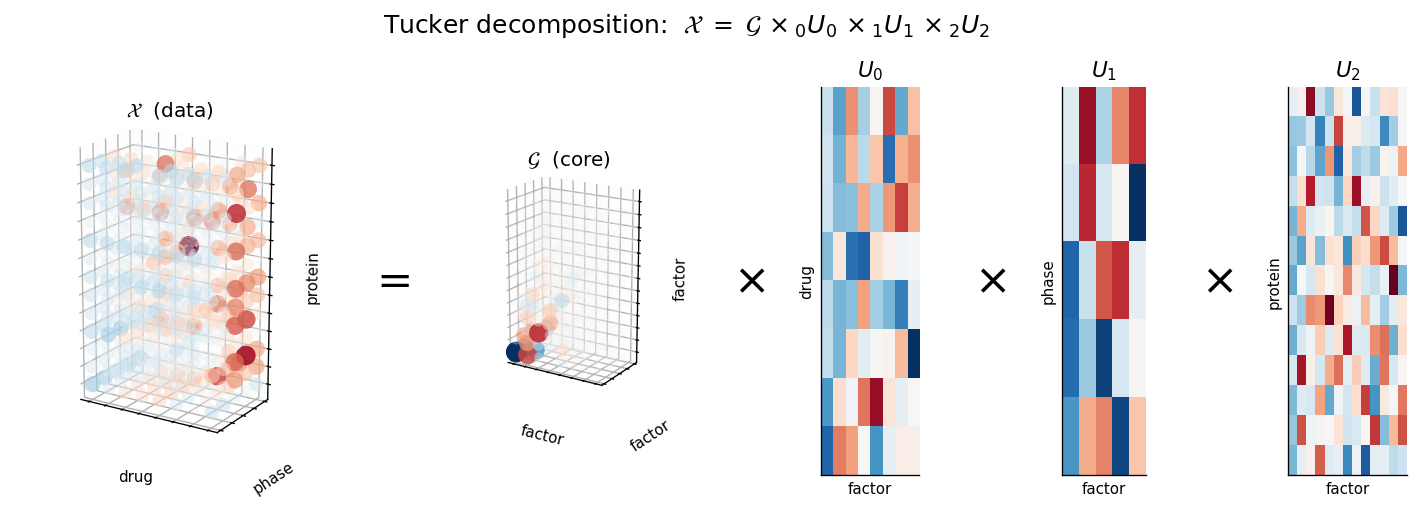

In [63]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 4.2))
gs = GridSpec(1, 9, width_ratios=[3.2, 0.6, 2.2, 0.7, 1.0, 0.7, 0.85, 0.7, 1.2], wspace=0.3)

def _glyph(col, s):
    a = fig.add_subplot(gs[0, col]); a.axis("off")
    a.text(0.5, 0.5, s, ha="center", va="center", fontsize=26)

def _factor_panel(col, U, name, rowname):
    a = fig.add_subplot(gs[0, col])
    vmax = np.abs(U).max() or 1.0
    a.imshow(U, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    a.set_title(name, fontsize=13)
    a.set_xlabel("factor", fontsize=9); a.set_ylabel(rowname, fontsize=9)
    a.set_xticks([]); a.set_yticks([])


ax0 = fig.add_subplot(gs[0, 0], projection="3d")

scatter3d(
    ax0, pseudobulk_tensor, axis_names=("drug", "phase", "protein"),
    title=r"$\mathcal{X}$  (data)", show_ticks=False, smax=140
)
_glyph(1, "=")
ax1 = fig.add_subplot(gs[0, 2], projection="3d")
scatter3d(
    ax1, core, axis_names=("factor", "factor", "factor"),
    title=r"$\mathcal{G}$  (core)", show_ticks=False, smax=140
)
_glyph(3, r"$\times$")
_factor_panel(4, factors[0], r"$U_0$", "drug")
_glyph(5, r"$\times$")
_factor_panel(6, factors[1], r"$U_1$", "phase")
_glyph(7, r"$\times$")
_factor_panel(8, factors[2], r"$U_2$", "protein")

fig.suptitle(
    r"Tucker decomposition:  $\mathcal{X} \;=\; \mathcal{G}\,\times_0 U_0\,\times_1 U_1\,\times_2 U_2$",
    fontsize=15, y=1.03
)
plt.show()

---

**2) Factor matrices $U_0$, $U_1$, $U_2$:**

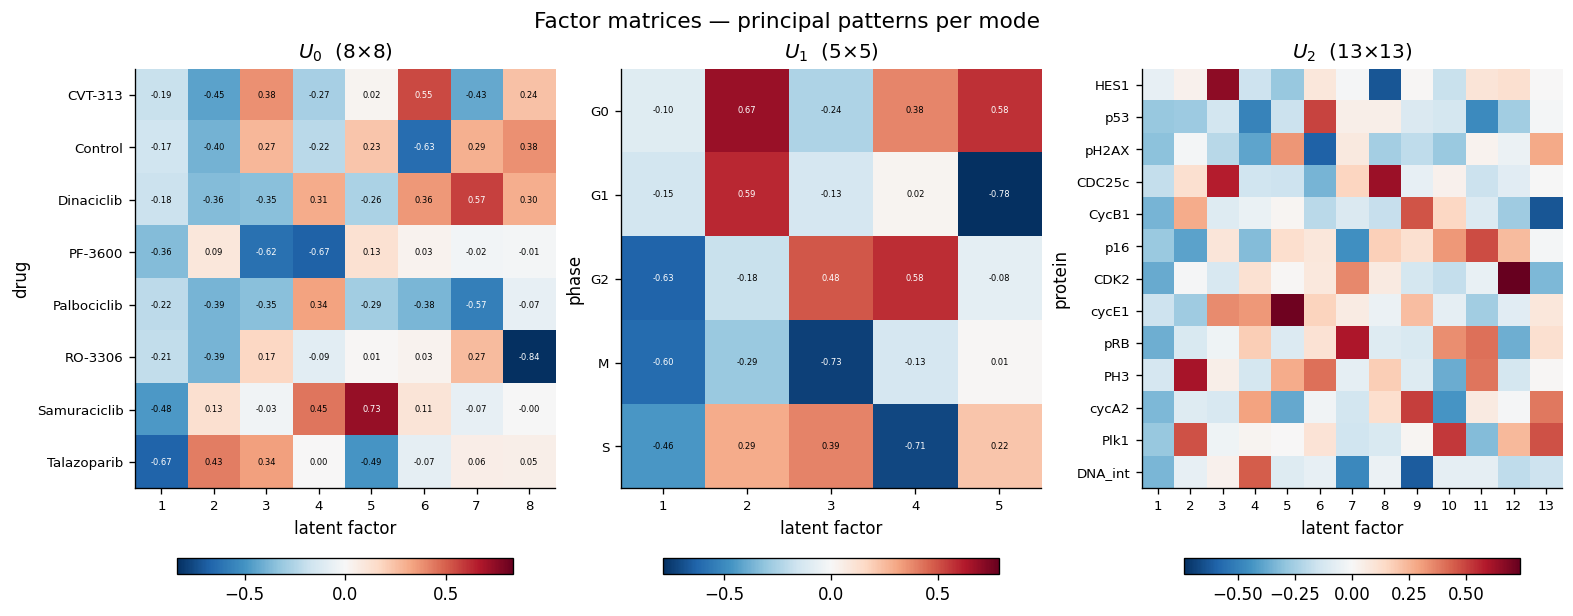

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True)

panels = [
    (factors[0], "U_0", "drug", drugs),
    (factors[1], "U_1", "phase", phases),
    (factors[2], "U_2", "protein", proteins)
]

for ax, (U, name, rowname, rowlabs) in zip(axes, panels):
    vmax = np.abs(U).max() or 1.0
    
    im = ax.imshow(U, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    
    ax.set_title(rf"${name}$  ({U.shape[0]}$\times${U.shape[1]})", fontsize=12)
    ax.set_xticks(np.arange(U.shape[1])); ax.set_xticklabels(np.arange(1, U.shape[1] + 1), fontsize=8)
    ax.set_xlabel("latent factor", fontsize=10)
    ax.set_yticks(np.arange(U.shape[0])); ax.set_yticklabels(rowlabs, fontsize=8)
    ax.set_ylabel(rowname, fontsize=10)
    
    if U.size <= 100:  # annotate small matrices
        for i in range(U.shape[0]):
            for j in range(U.shape[1]):
                ax.text(
                    j, i, f"{U[i, j]:.2f}", ha="center", va="center", fontsize=5,
                    color="white" if abs(U[i, j]) > 0.6 * vmax else "black"
                )
                
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, pad=0.04)

fig.suptitle("Factor matrices — principal patterns per mode", fontsize=13)
plt.show()

---

**3) Original tensor vs core, as 3-D voxel cubes:**

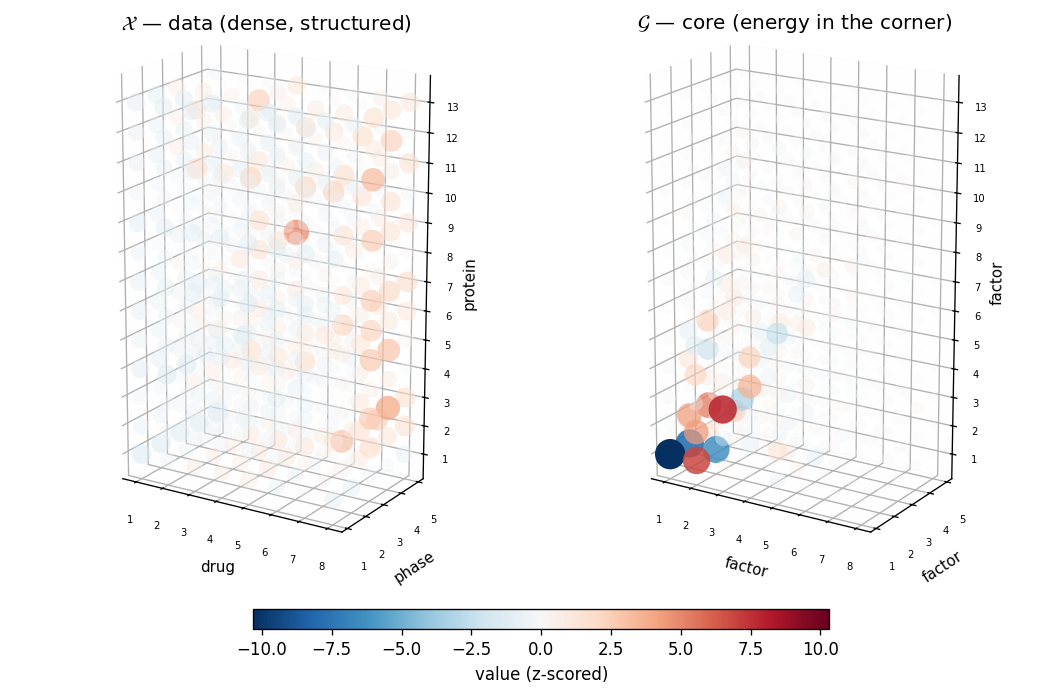

In [67]:
vmax = max(np.abs(pseudobulk_tensor).max(), np.abs(core).max())
fig = plt.figure(figsize=(12, 5.5))

ax0 = fig.add_subplot(1, 2, 1, projection="3d")
scatter3d(
    ax0, pseudobulk_tensor, vmax=vmax, axis_names=("drug", "phase", "protein"),
    title=r"$\mathcal{X}$ — data (dense, structured)"
)

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
sm = scatter3d(
    ax1, core, vmax=vmax, axis_names=("factor", "factor", "factor"),
    title=r"$\mathcal{G}$ — core (energy in the corner)"
)

cax = fig.add_axes([0.32, -0.02, 0.4, 0.03])
fig.colorbar(sm, cax=cax, orientation="horizontal", label="value (z-scored)")
  
fig.subplots_adjust(wspace=-0.1)
plt.show()

---

**4.1) Original tensor as slice montage:**

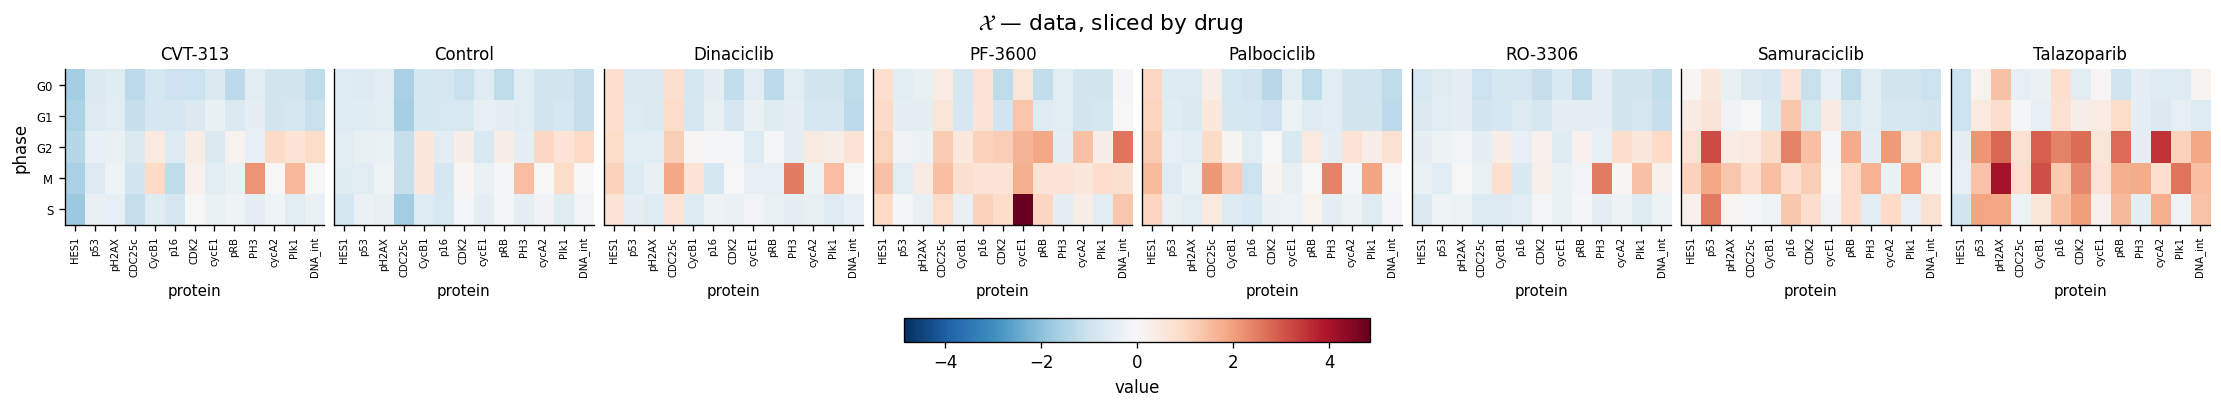

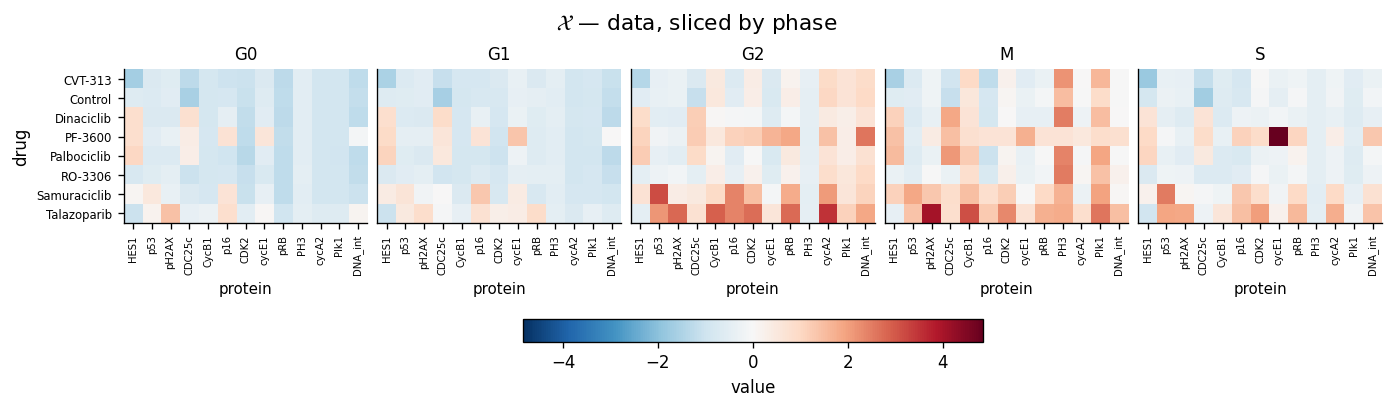

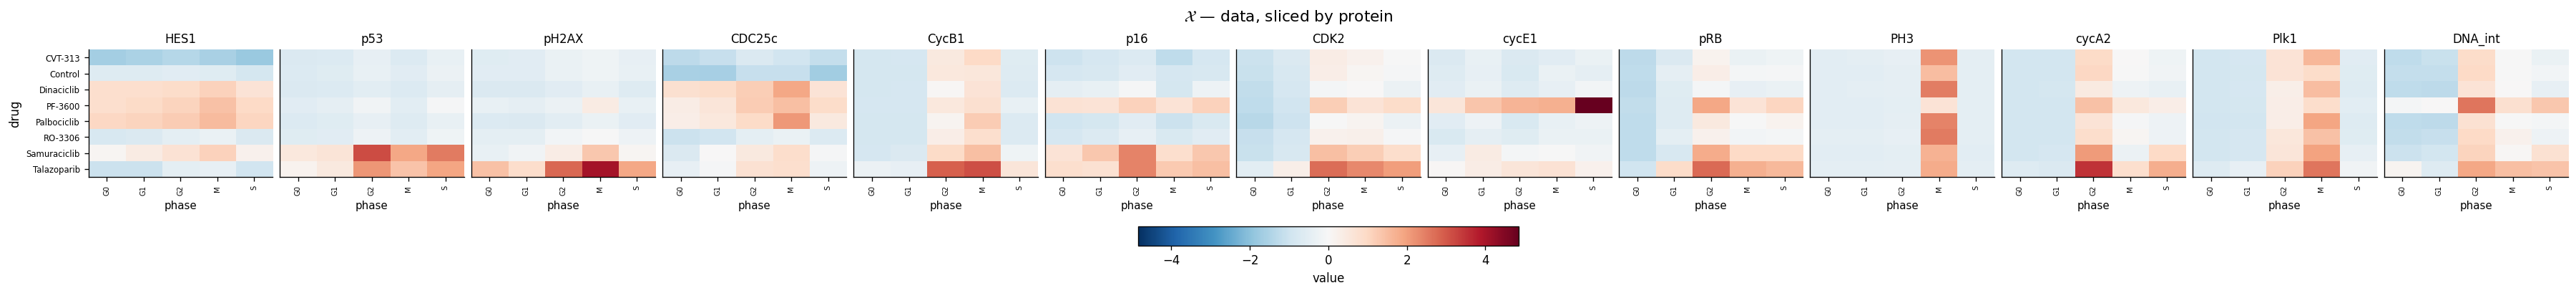

In [68]:
slice_montage(
    pseudobulk_tensor, axis=0,
    mode_names=("drug", "phase", "protein"),
    mode_ticklabels=(drugs, phases, proteins),
    title=r"$\mathcal{X}$ — data, sliced by drug"
)

slice_montage(
    pseudobulk_tensor, axis=1,
    mode_names=("drug", "phase", "protein"),
    mode_ticklabels=(drugs, phases, proteins),
    title=r"$\mathcal{X}$ — data, sliced by phase"
)

slice_montage(
    pseudobulk_tensor, axis=2,
    mode_names=("drug", "phase", "protein"),
    mode_ticklabels=(drugs, phases, proteins),
    title=r"$\mathcal{X}$ — data, sliced by protein"
)

plt.show()

**4.2) Core tensor as slice montage:**

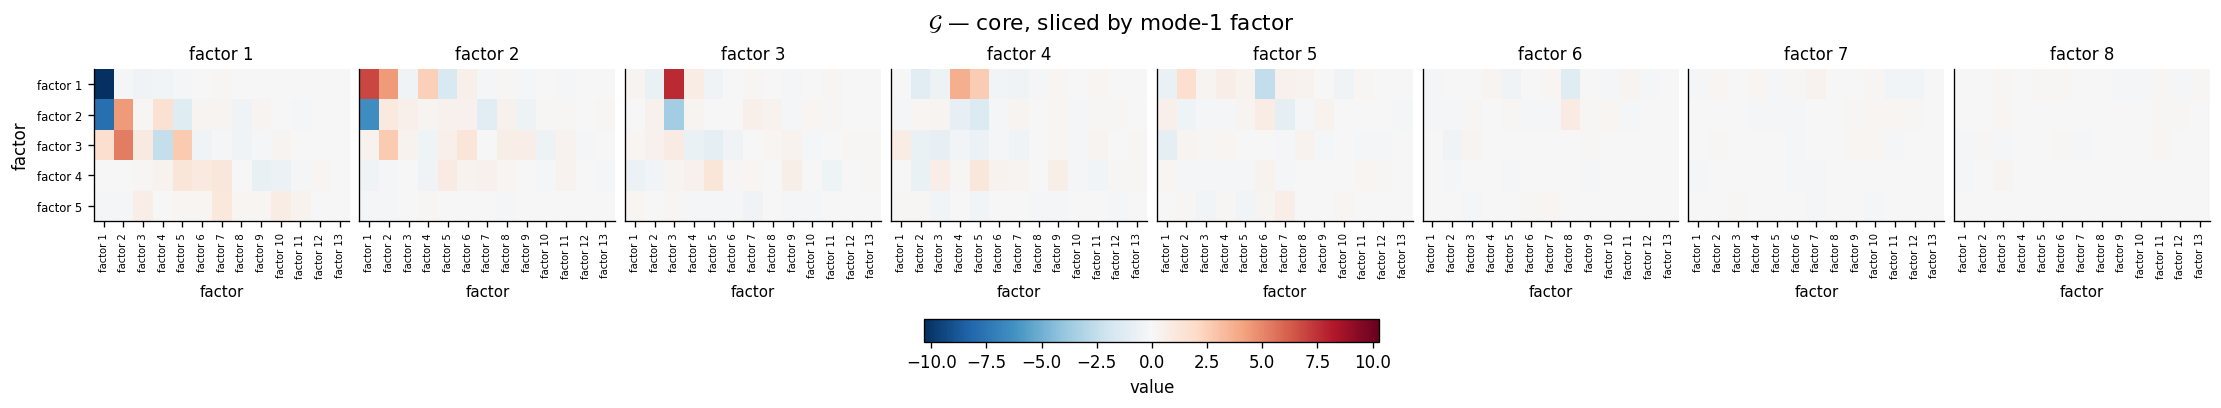

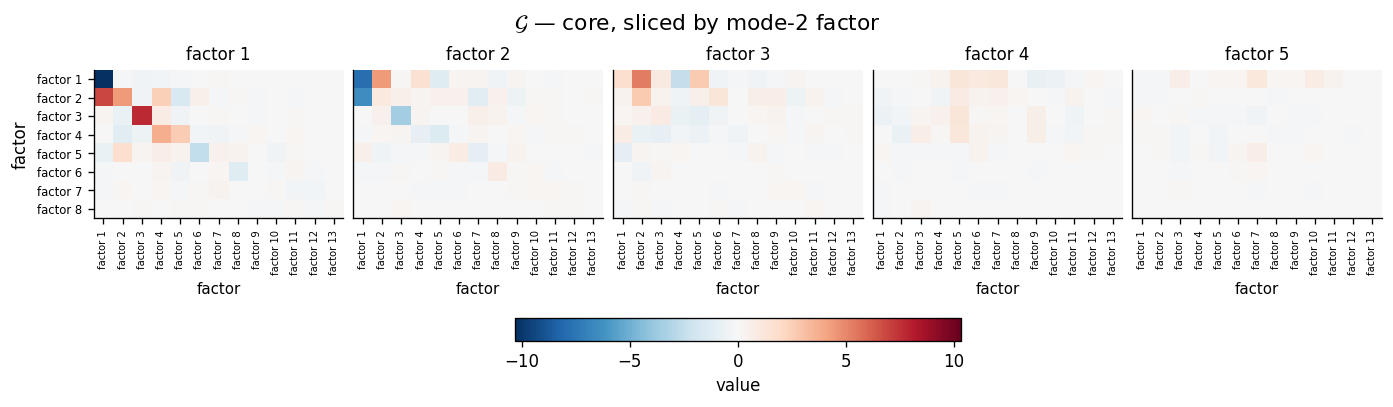

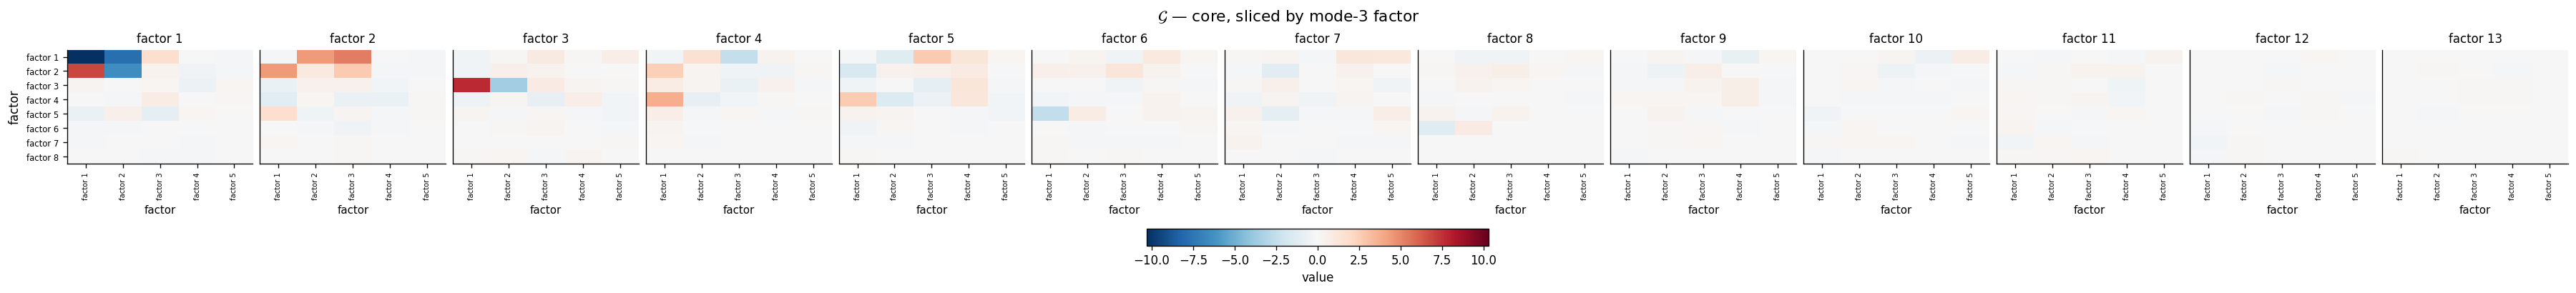

In [69]:
slice_montage(
    core, axis=0,
    mode_names=("factor", "factor", "factor"),
    mode_ticklabels=(None, None, None),
    title=r"$\mathcal{G}$ — core, sliced by mode-1 factor"
)

slice_montage(
    core, axis=1,
    mode_names=("factor", "factor", "factor"),
    mode_ticklabels=(None, None, None),
    title=r"$\mathcal{G}$ — core, sliced by mode-2 factor"
)

slice_montage(
    core, axis=2,
    mode_names=("factor", "factor", "factor"),
    mode_ticklabels=(None, None, None),
    title=r"$\mathcal{G}$ — core, sliced by mode-3 factor"
)

plt.show()

---

**5) The three single-mode products  $G \times_n U_n$,  as 3-D voxel cubes:**

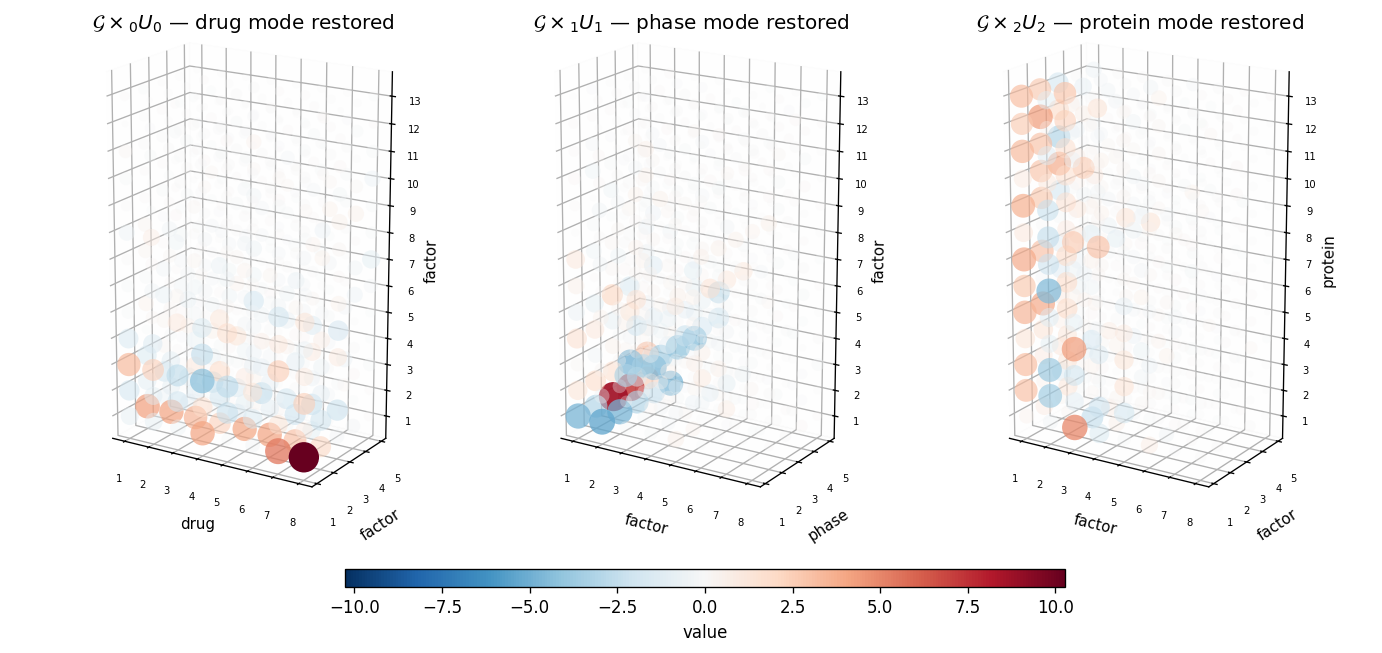

In [70]:
prods = [tenalg.mode_dot(core, factors[n], mode=n) for n in range(3)]
vmax = max(np.abs(p).max() for p in prods)

names = [("drug", "factor", "factor"), ("factor", "phase", "factor"), ("factor", "factor", "protein")]
titles = [
    r"$\mathcal{G}\times_0 U_0$ — drug mode restored",
    r"$\mathcal{G}\times_1 U_1$ — phase mode restored",
    r"$\mathcal{G}\times_2 U_2$ — protein mode restored"
]

fig = plt.figure(figsize=(15, 5))

for n in range(3):
    ax = fig.add_subplot(1, 3, n + 1, projection="3d")
    sm = scatter3d(ax, prods[n], vmax=vmax, axis_names=names[n], title=titles[n])

cax = fig.add_axes([0.32, -0.04, 0.4, 0.03])
fig.colorbar(sm, cax=cax, orientation="horizontal", label="value")
  
fig.subplots_adjust(wspace=-0.1)
plt.show()

---

**6) Three single-mode products  $G \times_n U_n$,  as slice montages**

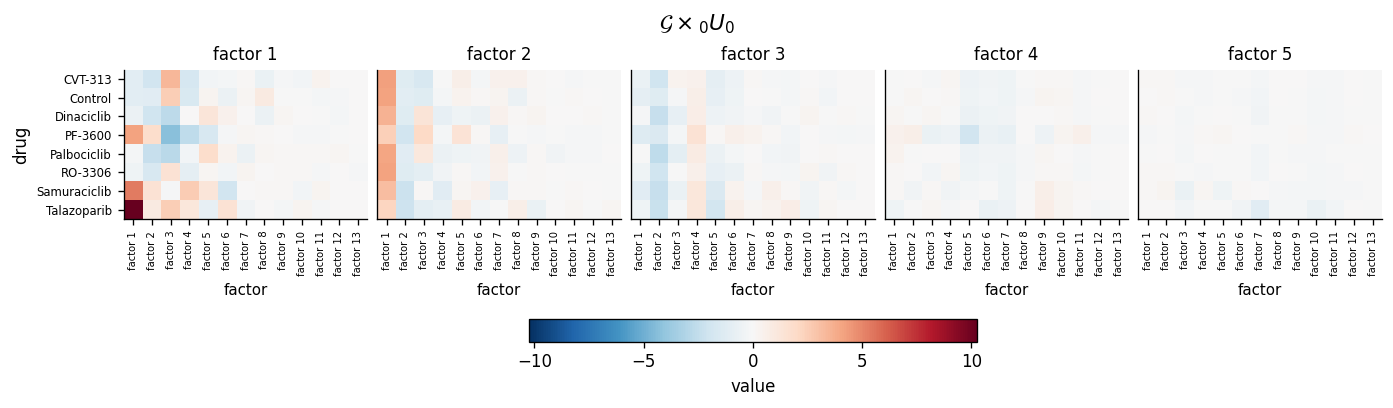

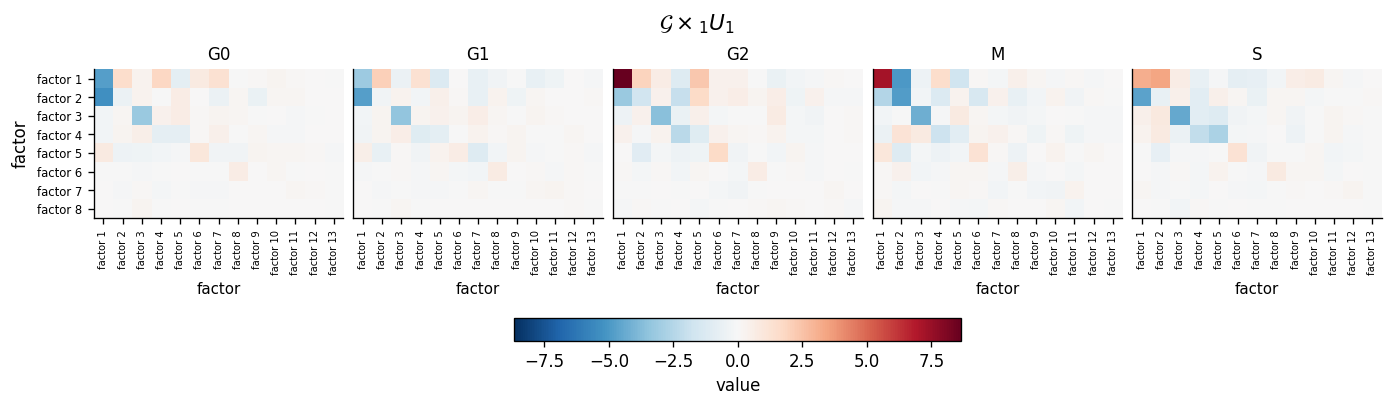

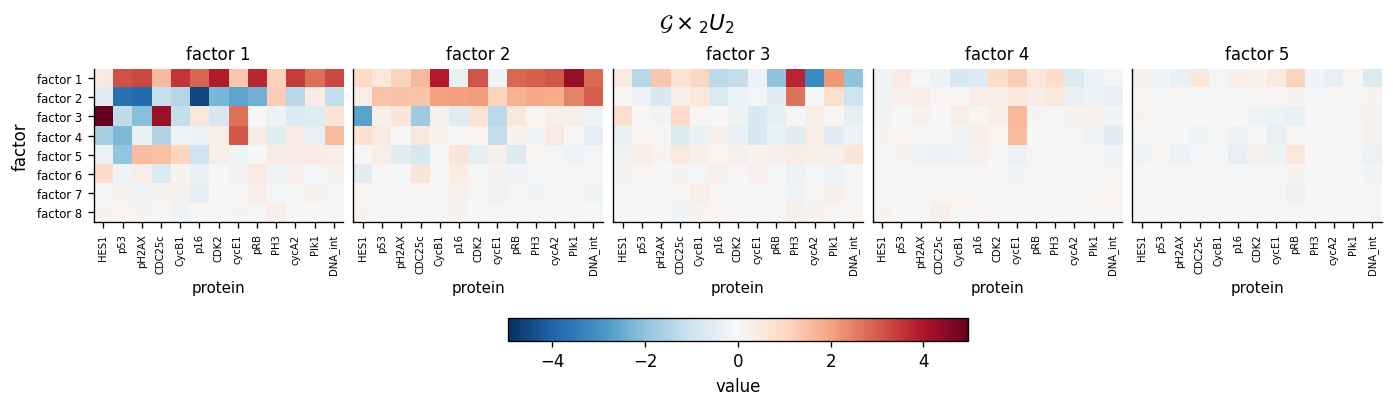

In [71]:
prods = [tenalg.mode_dot(core, factors[n], mode=n) for n in range(3)]

ticklabs = [(drugs, None, None), (None, phases, None), (None, None, proteins)]
names = [("drug", "factor", "factor"), ("factor", "phase", "factor"), ("factor", "factor", "protein")]
titles = [r"$\mathcal{G}\times_0 U_0$", r"$\mathcal{G}\times_1 U_1$", r"$\mathcal{G}\times_2 U_2$"]

for n in range(3):
    slice_montage(prods[n], axis=1, mode_names=names[n], mode_ticklabels=ticklabs[n], title=titles[n])

plt.show()

---

**7) Cumulative reconstruction:**

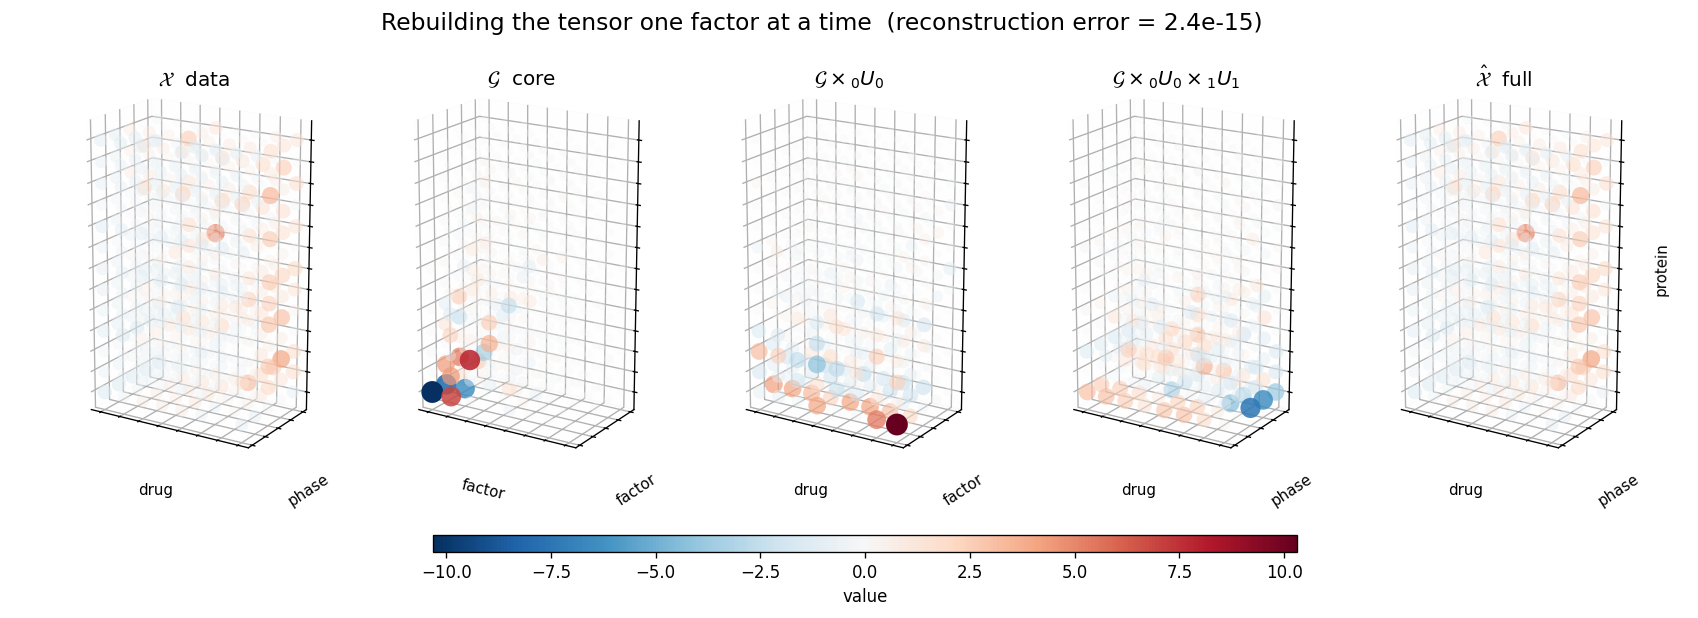

In [72]:
steps = [
    (pseudobulk_tensor, r"$\mathcal{X}$  data", ("drug", "phase", "protein")),
    (core, r"$\mathcal{G}$  core", ("factor", "factor", "factor")),
    (tenalg.mode_dot(core, factors[0], 0), r"$\mathcal{G}\times_0 U_0$", ("drug", "factor", "factor")),
    (tenalg.multi_mode_dot(core, [factors[0], factors[1]], modes=[0, 1]),
    r"$\mathcal{G}\times_0 U_0\times_1 U_1$", ("drug", "phase", "factor")),
    (tenalg.multi_mode_dot(core, factors), r"$\hat{\mathcal{X}}$  full", ("drug", "phase", "protein")),
]

recon = steps[-1][0]
err = np.linalg.norm(recon - pseudobulk_tensor) / np.linalg.norm(pseudobulk_tensor)
vmax = np.abs(core).max()

fig = plt.figure(figsize=(18, 4.5))

for i, (T, ttl, nm) in enumerate(steps):
    ax = fig.add_subplot(1, 5, i + 1, projection="3d")
    sm = scatter3d(ax, T, vmax=vmax, axis_names=nm, title=ttl, show_ticks=False, smax=160)

fig.suptitle(f"Rebuilding the tensor one factor at a time  (reconstruction error = {err:.1e})", fontsize=14)

cax = fig.add_axes([0.32, -0.02, 0.4, 0.03])
fig.colorbar(sm, cax=cax, orientation="horizontal", label="value")
  
fig.subplots_adjust(wspace=-0.1)
plt.show()

---